# Evaluierung & Analyse des Metrik-Gewichtungs-Experiments auf dem Lebenshilfe-Datensatz

Dieses Notebook analysiert und vergleicht das **Encoder-Decoder-Übersetzungsmodell (`facebook/mbart-large-50`)** unter systematisch variierten Gewichtungen der Verbund-Reward-Funktion (*Composite Reward*) im Direct Preference Optimization (DPO) Training:

$$R(x, y) = w_{\text{style}} \cdot R_{\text{style}}(y) + w_{\text{sem}} \cdot R_{\text{sem}}(x, y)$$

### Untersuchte Modellkonfigurationen:
1. **SFT Baseline:** Supervised Fine-Tuning Referenzmodell (`results/models/sft`)
2. **DPO `w05_w05`:** Ausgewogenes Modell mit $w_{\text{style}}=0.5, w_{\text{sem}}=0.5$ (`results/models/metric_weights_exp/dpo_w05_w05`)
3. **DPO `w07_w03`:** Priorisierte Vereinfachung mit $w_{\text{style}}=0.7, w_{\text{sem}}=0.3$ (`results/models/metric_weights_exp/dpo_w07_w03`)
4. **DPO `w10_w00`:** Maximale Simplicity ohne Semantik-Führung $w_{\text{style}}=1.0, w_{\text{sem}}=0.0$ (`results/models/metric_weights_exp/dpo_w10_w00`)

### Forschungsfragen:
- **F1 (Simplicity Gain):** Steigt der gemessene Simplicity-Score ($R_{\text{style}}$) kontinuierlich mit wachsendem $w_{\text{style}}$?
- **F2 (Information Loss & Truncation):** Ab welchem Gewichtungspunkt bricht der semantische Erhalt ($R_{\text{sem, AS}}$) ein oder treten aggressive Satzkürzungen/Satzabbrüche auf?
- **F3 (Pareto-Optimum):** Welches Gewichtungsverhältnis liefert die beste Balance zwischen verständlicher Leichter Sprache und inhaltlicher Korrektheit?

In [1]:
import os
import sys
import json
import glob
import random
from collections import Counter
from typing import List, Dict, Any, Tuple

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm
from IPython.display import display
import torch

def find_repo_root():
    p = os.path.abspath(os.getcwd())
    while p != os.path.dirname(p):
        if os.path.exists(os.path.join(p, 'data')) and os.path.exists(os.path.join(p, 'results')):
            return p
        p = os.path.dirname(p)
    return os.path.abspath(os.path.expanduser('~/Documents/Master Thesis'))

REPO_ROOT = find_repo_root()
os.chdir(REPO_ROOT)
if REPO_ROOT not in sys.path:
    sys.path.insert(0, REPO_ROOT)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else ('mps' if torch.backends.mps.is_available() else 'cpu'))
print('Arbeitsverzeichnis:', os.getcwd())
print(f'Nutze Device: {DEVICE}')

# Konfiguration & Pfade
LH_DATASET_PATH = os.path.join(REPO_ROOT, 'data/lebenshilfe/lebenshilfe_dataset_clean.json')
if not os.path.exists(LH_DATASET_PATH):
    LH_DATASET_PATH = os.path.join(REPO_ROOT, 'data/lebenshilfe/lebenshilfe_dataset.json')
MAX_SAMPLES = None

MODELS_CONFIG = {
    'SFT Baseline': {'color': '#4c72b0'},
    'DPO (0.5 Style / 0.5 Sem)': {'color': '#55a868'},
    'DPO (0.7 Style / 0.3 Sem)': {'color': '#e24a33'},
    'DPO (1.0 Style / 0.0 Sem)': {'color': '#8172b3'},
}

sns.set_theme(style='whitegrid', palette='deep')
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['figure.dpi'] = 150


Arbeitsverzeichnis: /Users/fietescheel/Documents/Master Thesis
Nutze Device: mps


## 1. Aggregierte Evaluationsergebnisse laden

Einlesen der Benchmark-Ergebnisse und des Lebenshilfe-Datensatzes.

In [2]:
SUMMARY_CSV = os.path.join(REPO_ROOT, 'results/evaluation/metric_weights_comparison_summary.csv')
DETAILS_CSV = os.path.join(REPO_ROOT, 'results/evaluation/metric_weights_comparison_details.csv')
LH_DATASET_PATH = os.path.join(REPO_ROOT, 'data/lebenshilfe/lebenshilfe_dataset.json')
os.makedirs(os.path.join(REPO_ROOT, 'results/plots'), exist_ok=True)

if os.path.exists(SUMMARY_CSV):
    df_summary = pd.read_csv(SUMMARY_CSV)
    print(f'Zusammenfassung erfolgreich geladen: {len(df_summary)} Modelle aus {SUMMARY_CSV}')
    display(df_summary)
else:
    print(f'Warnung: {SUMMARY_CSV} nicht gefunden.')
    df_summary = pd.DataFrame()

if os.path.exists(DETAILS_CSV):
    df_details = pd.read_csv(DETAILS_CSV)
    print(f'Detail-Ergebnisse erfolgreich geladen: {len(df_details)} Zeilen aus {DETAILS_CSV}')
else:
    print(f'Warnung: {DETAILS_CSV} nicht gefunden.')
    df_details = pd.DataFrame()

with open(LH_DATASET_PATH, 'r', encoding='utf-8') as f:
    lh_data = json.load(f)
print(f'Lebenshilfe Datensatz geladen: {len(lh_data)} Artikel-Paare.')

Zusammenfassung erfolgreich geladen: 4 Modelle aus /Users/fietescheel/Documents/Master Thesis/results/evaluation/metric_weights_comparison_summary.csv


,model_name,model_path,r_style_mean,r_sem_as_mean,sim_ref_mean,reward_05_05_mean,reward_07_03_mean,reward_10_00_mean,bleu_mean,rouge1_f1_mean,rouge2_f1_mean,rougeL_f1_mean,avg_src_tokens,avg_gen_tokens,avg_ref_tokens,compression_ratio_mean,truncation_rate
0,SFT Baseline,results/models/sft,0.583472,0.871756,0.863339,0.727614,0.669957,0.583472,0.009097,0.211657,0.066753,0.113417,916.459459,145.864865,1107.324324,0.364411,0.486486
1,DPO (0.5 Style / 0.5 Sem),results/models/metric_weights_exp/dpo_w05_w05,0.628038,0.609012,0.626716,0.618525,0.622330,0.628038,0.002650,0.133142,0.027963,0.075431,916.459459,133.756757,1107.324324,0.272134,0.459459
2,DPO (0.7 Style / 0.3 Sem),results/models/metric_weights_exp/dpo_w07_w03,0.750362,0.602435,0.624820,0.676398,0.705984,0.750362,0.001027,0.190060,0.041547,0.106641,916.459459,171.756757,1107.324324,0.397690,0.486486
3,DPO (1.0 Style / 0.0 Sem),results/models/metric_weights_exp/dpo_w10_w00,0.777171,0.590099,0.620691,0.683635,0.721049,0.777171,0.000957,0.167765,0.031720,0.102906,916.459459,169.405405,1107.324324,0.371297,0.594595


Detail-Ergebnisse erfolgreich geladen: 148 Zeilen aus /Users/fietescheel/Documents/Master Thesis/results/evaluation/metric_weights_comparison_details.csv
Lebenshilfe Datensatz geladen: 49 Artikel-Paare.


## 2. Quantitative Vergleichstabelle

In [3]:
if 'df_summary' in locals() and len(df_summary) > 0:
    styled_df = df_summary.copy()
    for col in styled_df.columns:
        if col != "Modell" and col != "model_name":
            styled_df[col] = styled_df[col].apply(lambda x: f"{x:.4f}" if isinstance(x, (float, int, np.floating)) else x)
    display(styled_df)
    
    print("\n=== Markdown-Tabelle  ===\n")
    try:
        print(styled_df.to_markdown(index=False))
    except Exception:
        cols = [str(c) for c in styled_df.columns]
        header = "| " + " | ".join(cols) + " |"
        sep = "| " + " | ".join(["---"] * len(cols)) + " |"
        rows = ["| " + " | ".join([str(val) for val in row]) + " |" for row in styled_df.values]
        print("\n".join([header, sep] + rows))
else:
    print("Keine Zusammenfassungstabelle verfuegbar.")

,model_name,model_path,r_style_mean,r_sem_as_mean,sim_ref_mean,reward_05_05_mean,reward_07_03_mean,reward_10_00_mean,bleu_mean,rouge1_f1_mean,rouge2_f1_mean,rougeL_f1_mean,avg_src_tokens,avg_gen_tokens,avg_ref_tokens,compression_ratio_mean,truncation_rate
0,SFT Baseline,results/models/sft,0.5835,0.8718,0.8633,0.7276,0.6700,0.5835,0.0091,0.2117,0.0668,0.1134,916.4595,145.8649,1107.3243,0.3644,0.4865
1,DPO (0.5 Style / 0.5 Sem),results/models/metric_weights_exp/dpo_w05_w05,0.6280,0.6090,0.6267,0.6185,0.6223,0.6280,0.0027,0.1331,0.0280,0.0754,916.4595,133.7568,1107.3243,0.2721,0.4595
2,DPO (0.7 Style / 0.3 Sem),results/models/metric_weights_exp/dpo_w07_w03,0.7504,0.6024,0.6248,0.6764,0.7060,0.7504,0.0010,0.1901,0.0415,0.1066,916.4595,171.7568,1107.3243,0.3977,0.4865
3,DPO (1.0 Style / 0.0 Sem),results/models/metric_weights_exp/dpo_w10_w00,0.7772,0.5901,0.6207,0.6836,0.7210,0.7772,0.0010,0.1678,0.0317,0.1029,916.4595,169.4054,1107.3243,0.3713,0.5946



=== Markdown-Tabelle  ===

| model_name                | model_path                                    |   r_style_mean |   r_sem_as_mean |   sim_ref_mean |   reward_05_05_mean |   reward_07_03_mean |   reward_10_00_mean |   bleu_mean |   rouge1_f1_mean |   rouge2_f1_mean |   rougeL_f1_mean |   avg_src_tokens |   avg_gen_tokens |   avg_ref_tokens |   compression_ratio_mean |   truncation_rate |
|:--------------------------|:----------------------------------------------|---------------:|----------------:|---------------:|--------------------:|--------------------:|--------------------:|------------:|-----------------:|-----------------:|-----------------:|-----------------:|-----------------:|-----------------:|-------------------------:|------------------:|
| SFT Baseline              | results/models/sft                            |         0.5835 |          0.8718 |         0.8633 |              0.7276 |              0.67   |              0.5835 |      0.0091 |           0.2117 |  

## 3. Visualisierungen & Trade-off-Kurven (Pareto-Frontier)

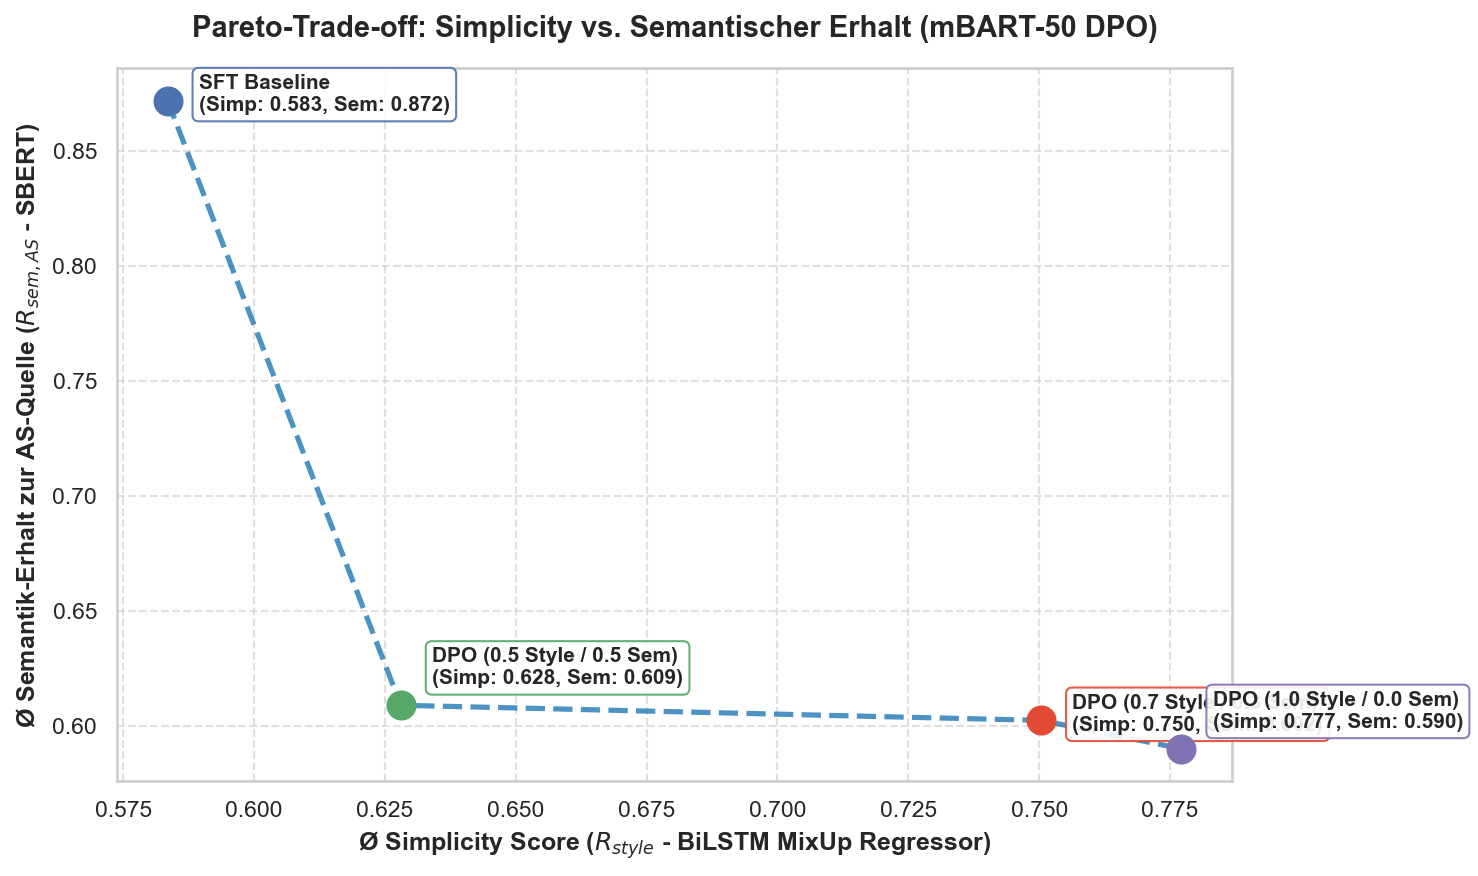

In [4]:
if 'df_summary' in locals() and len(df_summary) > 0:
    simp_col = [c for c in df_summary.columns if "Simplicity" in c or "r_style" in c][0]
    sem_col = [c for c in df_summary.columns if "Semantik" in c or "r_sem" in c][0]
    name_col = [c for c in df_summary.columns if "Modell" in c or "model" in c][0]
    
    fig, ax = plt.subplots(figsize=(10, 6))
    
    x_vals = df_summary[simp_col].astype(float)
    y_vals = df_summary[sem_col].astype(float)
    
    ax.plot(x_vals, y_vals, marker="o", markersize=12, linewidth=2.5, color="#1f77b4", linestyle="--", alpha=0.8, label="Trade-off Pfad")
    
    for i, row in df_summary.iterrows():
        m_name = row[name_col]
        x_pt = float(row[simp_col])
        y_pt = float(row[sem_col])
        color = MODELS_CONFIG.get(m_name, {}).get("color", "#333333")
        ax.scatter([x_pt], [y_pt], color=color, s=180, zorder=5)
        ax.annotate(
            f"{m_name}\n(Simp: {x_pt:.3f}, Sem: {y_pt:.3f})",
            (x_pt, y_pt),
            textcoords="offset points",
            xytext=(15, -5 if i % 2 == 0 else 10),
            fontweight="bold",
            fontsize=10,
            bbox=dict(boxstyle="round,pad=0.3", fc="white", ec=color, alpha=0.9)
        )
        
    ax.set_xlabel("Ø Simplicity Score ($R_{style}$ - BiLSTM MixUp Regressor)", fontsize=12, fontweight="bold")
    ax.set_ylabel("Ø Semantik-Erhalt zur AS-Quelle ($R_{sem, AS}$ - SBERT)", fontsize=12, fontweight="bold")
    ax.set_title("Pareto-Trade-off: Simplicity vs. Semantischer Erhalt (mBART-50 DPO)", fontsize=14, fontweight="bold", pad=15)
    ax.grid(True, linestyle="--", alpha=0.6)
    plt.tight_layout()
    plt.savefig("results/plots/pareto_frontier_metric_weights.png", dpi=300)
    plt.show()
else:
    print("Keine Daten fuer Trade-off-Kurve vorhanden.")

/var/folders/b4/clxxd_yn5655dz4hq58pqznh0000gn/T/ipykernel_90334/2099564962.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_details, x="model_name", y="r_style", ax=axes[0], palette="Set2", showmeans=True)
/var/folders/b4/clxxd_yn5655dz4hq58pqznh0000gn/T/ipykernel_90334/2099564962.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_details, x="model_name", y="r_sem_as", ax=axes[1], palette="Set2", showmeans=True)


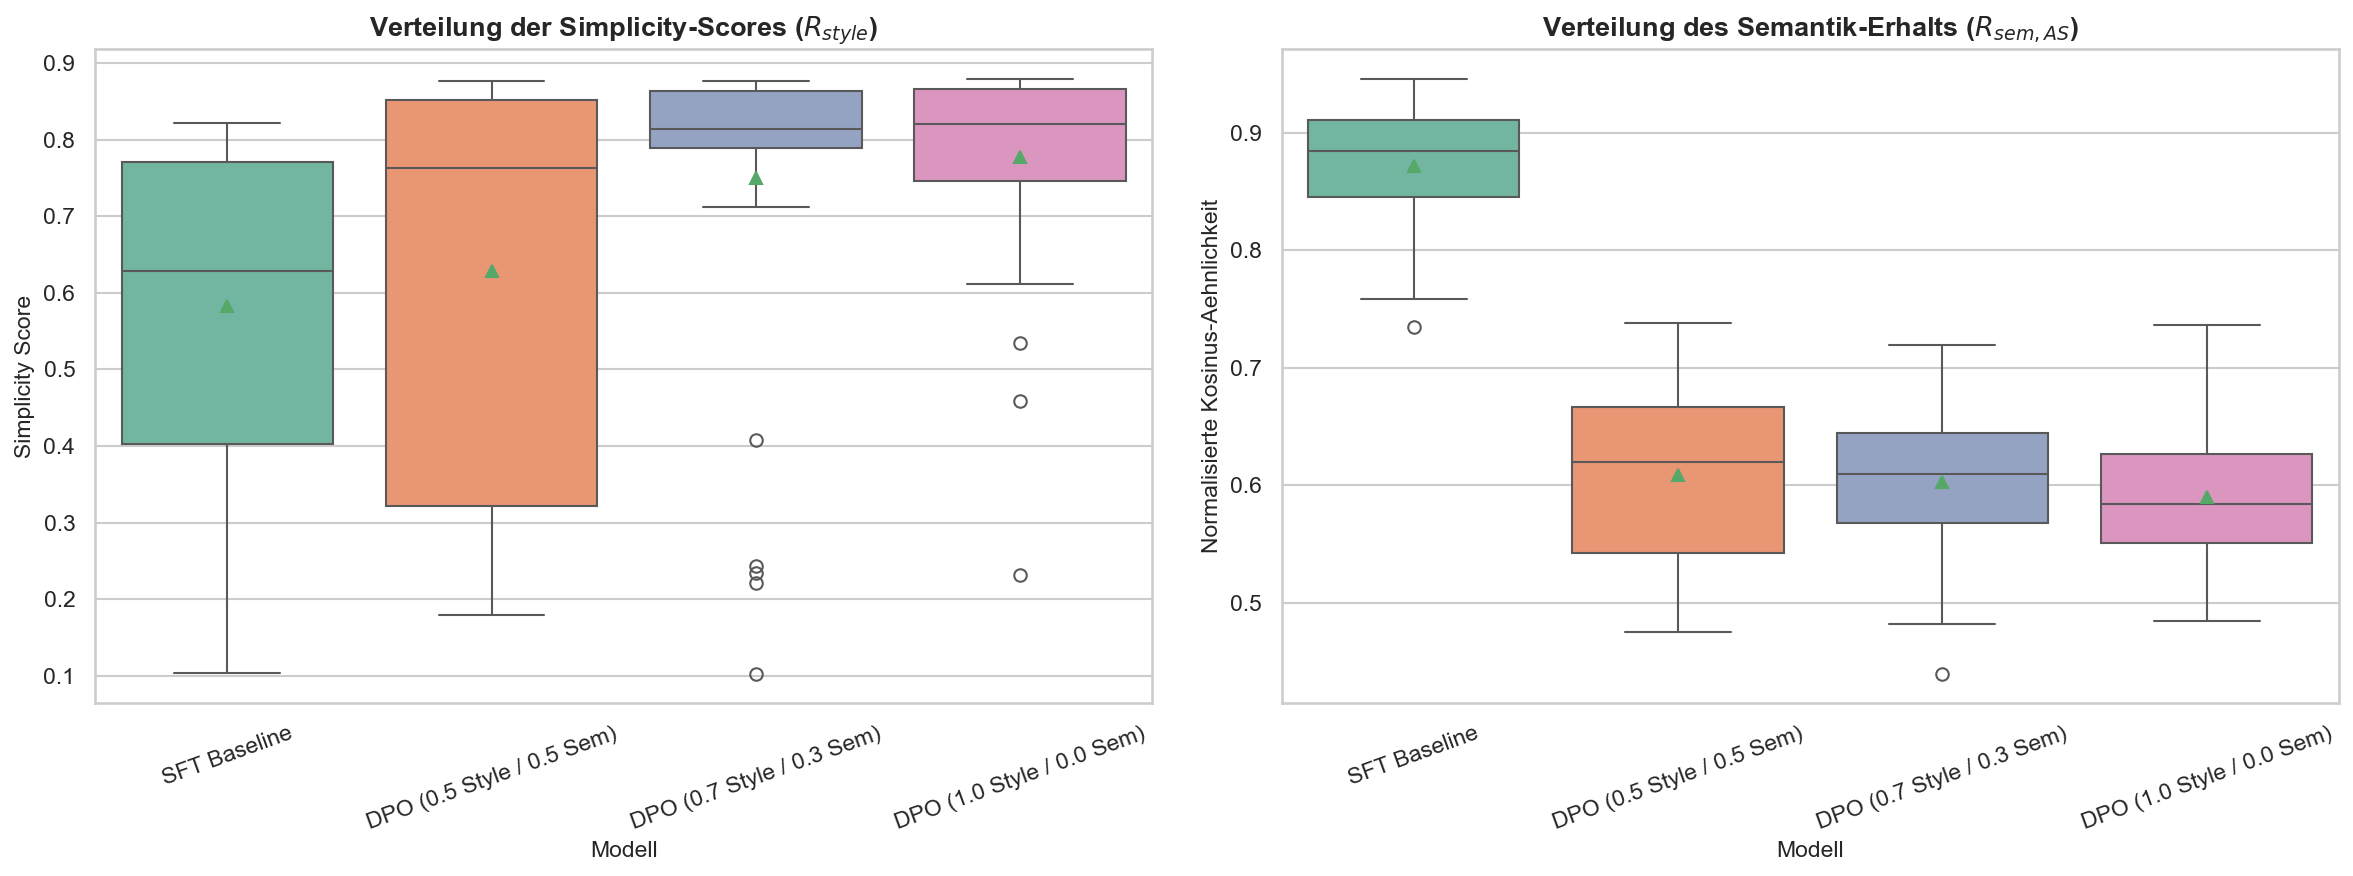

In [5]:
if 'df_details' in locals() and len(df_details) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    sns.boxplot(data=df_details, x="model_name", y="r_style", ax=axes[0], palette="Set2", showmeans=True)
    axes[0].set_title("Verteilung der Simplicity-Scores ($R_{style}$)", fontsize=13, fontweight="bold")
    axes[0].set_xlabel("Modell", fontsize=11)
    axes[0].set_ylabel("Simplicity Score", fontsize=11)
    axes[0].tick_params(axis='x', rotation=20)
    
    sns.boxplot(data=df_details, x="model_name", y="r_sem_as", ax=axes[1], palette="Set2", showmeans=True)
    axes[1].set_title("Verteilung des Semantik-Erhalts ($R_{sem, AS}$)", fontsize=13, fontweight="bold")
    axes[1].set_xlabel("Modell", fontsize=11)
    axes[1].set_ylabel("Normalisierte Kosinus-Aehnlichkeit", fontsize=11)
    axes[1].tick_params(axis='x', rotation=20)
    
    plt.tight_layout()
    plt.savefig("results/plots/score_distributions_metric_weights.png", dpi=300)
    plt.show()
else:
    print("Keine Detaildaten fuer Verteilungs-Plots vorhanden.")

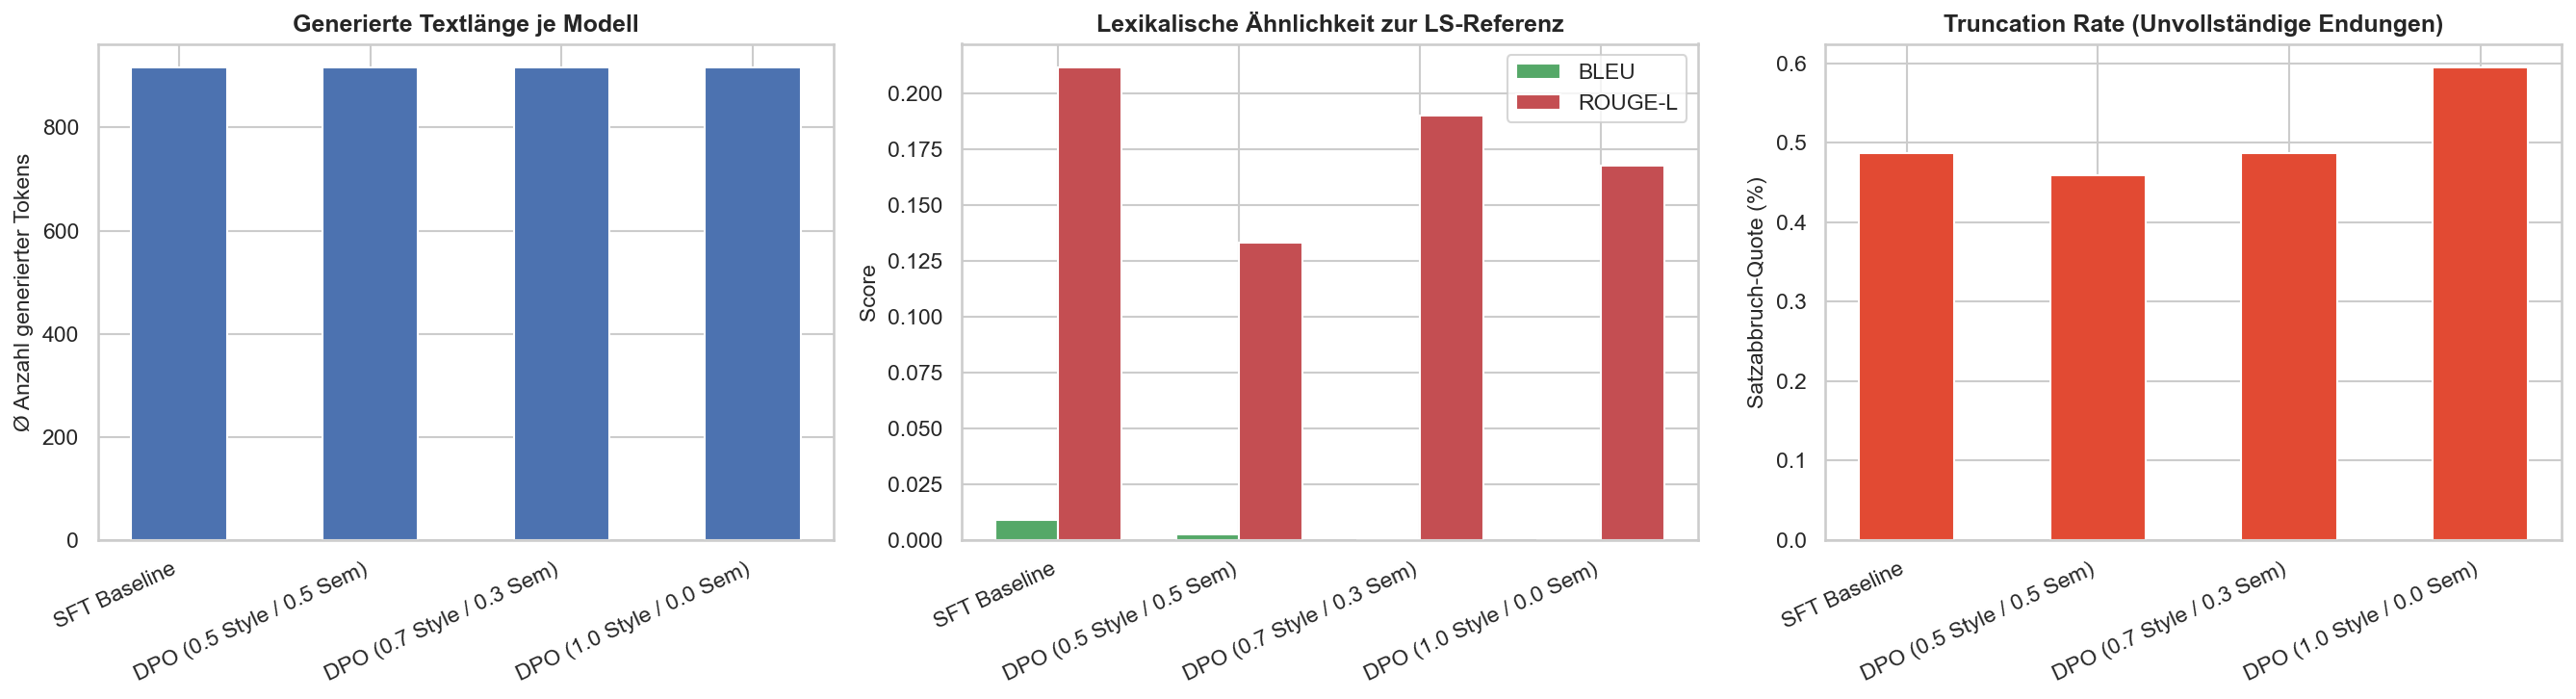

In [6]:
if 'df_summary' in locals() and len(df_summary) > 0:
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    name_col = [c for c in df_summary.columns if 'modell' in c.lower() or 'model' in c.lower()][0]
    models = df_summary[name_col]
    x = np.arange(len(models))
    
    tok_cols = [c for c in df_summary.columns if 'avg_gen_tokens' in c.lower() or 'tokens' in c.lower()]
    tok_col = tok_cols[0] if tok_cols else df_summary.columns[0]
    axes[0].bar(x, df_summary[tok_col].astype(float), color='#4c72b0', width=0.5)
    axes[0].set_xticks(x)
    axes[0].set_xticklabels(models, rotation=25, ha='right')
    axes[0].set_ylabel('Ø Anzahl generierter Tokens', fontsize=11)
    axes[0].set_title('Generierte Textlänge je Modell', fontsize=12, fontweight='bold')
    
    bleu_cols = [c for c in df_summary.columns if 'bleu' in c.lower()]
    rouge_cols = [c for c in df_summary.columns if 'rougel' in c.lower() or 'rouge_l' in c.lower() or 'rouge' in c.lower()]
    w = 0.35
    if bleu_cols and rouge_cols:
        axes[1].bar(x - w/2, df_summary[bleu_cols[0]].astype(float), width=w, label='BLEU', color='#55a868')
        axes[1].bar(x + w/2, df_summary[rouge_cols[0]].astype(float), width=w, label='ROUGE-L', color='#c44e52')
        axes[1].set_xticks(x)
        axes[1].set_xticklabels(models, rotation=25, ha='right')
        axes[1].set_ylabel('Score', fontsize=11)
        axes[1].set_title('Lexikalische Ähnlichkeit zur LS-Referenz', fontsize=12, fontweight='bold')
        axes[1].legend()
    
    trunc_cols = [c for c in df_summary.columns if 'trunc' in c.lower()]
    if trunc_cols:
        axes[2].bar(x, df_summary[trunc_cols[0]].astype(float), color='#e24a33', width=0.5)
        axes[2].set_xticks(x)
        axes[2].set_xticklabels(models, rotation=25, ha='right')
        axes[2].set_ylabel('Satzabbruch-Quote (%)', fontsize=11)
        axes[2].set_title('Truncation Rate (Unvollständige Endungen)', fontsize=12, fontweight='bold')
    
    plt.tight_layout()
    plt.savefig('results/plots/length_and_truncation_metric_weights.png', dpi=300)
    plt.show()
else:
    print('Keine Längendaten verfügbar.')


## 4. Qualitativer Side-by-Side Modellvergleich (Beispielsätze)

In [7]:
if 'df_details' in locals() and len(df_details) > 0:
    sample_queries = df_details["as_text"].unique()[:5]
    
    for idx, as_s in enumerate(sample_queries, 1):
        sub_df = df_details[df_details["as_text"] == as_s]
        ls_ref = sub_df["ls_ref_text"].iloc[0]
        
        print(f"\n{'#'*90}")
        print(f"BEISPIEL {idx}:")
        print(f"[AS Quelle] : {as_s}")
        print(f"[LS Referenz]: {ls_ref}")
        print(f"{'-'*90}")
        
        for _, r in sub_df.iterrows():
            print(f"[{r['model_name']:28s}] (Simp: {r['r_style']:.3f} | Sem-AS: {r['r_sem_as']:.3f} | Tokens: {r['gen_tokens']}):")
            print(f"  {r['generated_text']}\n")
else:
    print("Keine Detail-Uebersetzungen verfuegbar.")


##########################################################################################
BEISPIEL 1:
[AS Quelle] : Kiel, 15.10.2020. Arbeit zweiter oder dritter Klasse?? - Positionspapier Die Rede ist in diesemFall von der Entlohnung für Menschen, die in einer Werkstatt (WfbM) arbeiten. Wichtiges Detail: Es sind die Werkstätten selbst, die diese Veränderung dringend fordern. Der Lohn der Mitarbeiter*innen mit Werkstattvertrag ist bei einem 6 – 8 Stunden Arbeitstag weit davon entfernt, auf dieser Basis ein selbstfinanziertes Leben führen zu können. Das bedeutet, dass die Menschen grundsätzlich Grundsicherung beantragen müssen, um ihren Lebensunterhalt zu bestreiten – es sei denn, sie erhalten bereits eine Erwerbsminderungsrente und können in der Werkstatt noch so viel dazu verdienen, dass es gerade zum Leben reicht. Die Pandemie-bedingten Betretungsverbote für die WfbMs und die damit aller Orten eingebrochenen Erträge machen die Auszahlung dieser Löhne nun aber auch immer schwieriger